# Tune parameters for a simple curve function

In [1]:
import matplotlib.pyplot as plt
import torch
import numpy as np

In [2]:
# First example: Function that has one dependent (y) & one independent variable (x)

def make_polynomial(coeffs: torch.Tensor):
    # Using Horner's method
    def f(x: torch.Tensor):
        y = torch.tensor(0.0)
        for coeff in coeffs:
            y = y * x + coeff
        return y
    return f

In [42]:
np.random.seed(2026)
torch.manual_seed(2026)
from ipywidgets.widgets import interact
@interact(a = -4.3, b = 0.7, c = 2.1)
def plot_quadratic(a, b, c):
    f = make_polynomial(torch.tensor([a, b, c]))
    x = torch.linspace(-3, 3, 50)
    plt.plot(x, f(x), color="red")

interactive(children=(FloatSlider(value=-4.3, description='a', max=4.3, min=-12.899999999999999), FloatSlider(…

In [79]:
# Add noise to the points using normal distribution and a scaling factor
def noise(x: torch.Tensor, mult: torch.Tensor, add: torch.Tensor):
    return x * (1 + torch.randn(size=x.shape) * mult) + torch.randn(size=x.shape) * add

In [83]:
# Generate the dataset for the chosen curve
f = make_polynomial(torch.tensor([-4.3, 0.7, 2.1]))
x = torch.linspace(-5, 5, 50)
y = noise(f(x), torch.tensor(0.50), torch.tensor(1.8))

In [84]:
# Define loss functions

def mae(predicted: torch.Tensor, actual: torch.Tensor):
    return torch.abs(predicted - actual).mean()

def mse(predicted: torch.Tensor, actual: torch.Tensor):
    return torch.square(predicted - actual).mean()
loss_function = mse

In [85]:
np.random.seed(2026)
torch.manual_seed(2026)
from ipywidgets.widgets import interact
@interact(a = 3.0, b = 1.0, c = 1.1)
def plot_quadratic(a, b, c):
    f = make_polynomial(torch.tensor([a, b, c]))
    y_pred = f(x)
    loss = loss_function(y_pred, y) # Loss of predicted vs actual
    plt.title(f"Plot of ${a}x^2 + {b}x + {c}$, loss: {loss:0.2f}")
    plt.plot(x, y_pred, color="red")
    plt.scatter(x, y, color="blue")

interactive(children=(FloatSlider(value=3.0, description='a', max=9.0, min=-3.0), FloatSlider(value=1.0, descr…

# Automate the finding of parameters using gradient descent 

In [105]:
param = torch.tensor([1.0, 1.0, 1.0])
param.requires_grad_()

loss = loss_function(make_polynomial(param)(x), y)
print(f"Initial loss: {loss}")

for i in range(50):
    loss = loss_function(make_polynomial(param)(x), y)
    loss.backward()
    # i.e. increase a & c and decrease b (negative of grad is used to minimize loss)
    with torch.no_grad():
        param -= param.grad * 0.001
        param.grad.zero_() # This line is needed, otherwise the gradient will accumulate over the batch
    print(f"step = {i}, loss = {loss}")

Initial loss: 3970.916015625
step = 0, loss = 3970.916015625
step = 1, loss = 2238.439453125
step = 2, loss = 1319.7154541015625
step = 3, loss = 832.5098266601562
step = 4, loss = 574.131103515625
step = 5, loss = 437.0955810546875
step = 6, loss = 364.40679931640625
step = 7, loss = 325.84027099609375
step = 8, loss = 305.36883544921875
step = 9, loss = 294.49298095703125
step = 10, loss = 288.7063293457031
step = 11, loss = 285.6186218261719
step = 12, loss = 283.9624938964844
step = 13, loss = 283.06597900390625
step = 14, loss = 282.5726623535156
step = 15, loss = 282.29339599609375
step = 16, loss = 282.12823486328125
step = 17, loss = 282.0237121582031
step = 18, loss = 281.9517822265625
step = 19, loss = 281.8974304199219
step = 20, loss = 281.85272216796875
step = 21, loss = 281.8134460449219
step = 22, loss = 281.77734375
step = 23, loss = 281.74322509765625
step = 24, loss = 281.7103576660156
step = 25, loss = 281.6784973144531
step = 26, loss = 281.6474304199219
step = 27, 

In [87]:
# A learning rate scheduler is needed otherwise it'll overshoot when it's near the answer and the loss keeps jumping

tensor(281.0586, grad_fn=<MeanBackward0>)
tensor([-4.2115,  0.7960,  0.8632], requires_grad=True)


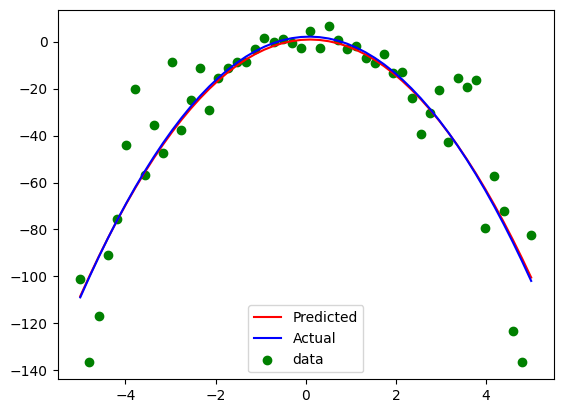

In [104]:
print(loss)
print(param)
with torch.no_grad():
    y_pred = make_polynomial(param)(x)
plt.plot(x, y_pred, color="red", label="Predicted")
plt.plot(x, f(x), color="blue", label="Actual")
plt.scatter(x, y, color="green", label="data")
plt.legend()